## 📑 Refrences

* [**Towards Data Science**](https://towardsdatascience.com/evaluation-metrics-for-recommendation-systems-an-overview-71290690ecba/)
* [**Medium**](https://medium.com/data-science/metrics-of-recommender-systems-cde64042127a)
* [**Evidently AI**](https://www.evidentlyai.com/ranking-metrics/evaluating-recommender-systems)

In [ ]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from Notebooks.Column import column
import re
import statistics

## 🟢 Loading Dataset

In [218]:
users = pd.read_csv("Datasets/Users.csv")
users.head()

,user_id,username,place_id,place_name,rating
0,04fab766-306b-4f35-a83e-4655f052392d,dina_ali,7,Obelisk of Senusret I,3
1,04fab766-306b-4f35-a83e-4655f052392d,dina_ali,71,Graeco-Roman Museum,2
2,04fab766-306b-4f35-a83e-4655f052392d,dina_ali,63,Alexandria Museum of Fine Arts,3
3,04fab766-306b-4f35-a83e-4655f052392d,dina_ali,58,Agricultural Museum,1
4,04fab766-306b-4f35-a83e-4655f052392d,dina_ali,36,Ras Mohammed National Park,5


In [219]:
rows , columns = users.shape
print(f"Users Dataset have {rows} row and {columns} Column")

Users Dataset have 1038 row and 5 Column


In [220]:
places = pd.read_csv("Datasets/Places.csv")
places.head()

,ID,Name,Description,Location,Latitude,Longitude,Type Of Site,Historical Era,Key Features,Opening Hours,Typical Visit Duration,Entry Fee,ImageLink
0,1,Pyramids of Giza,"Comprising the Great Pyramid of Khufu, the Pyr...",Giza,29.977494,31.132504,Ancient Sites,Pharaonic,"['Pharaonic tombs', 'UNESCO World Heritage Sit...",07:00 AM - 04:00 PM,2 - 3 hours,Foreigners Adult: 700 EGP\nForeigners Student:...,https://wsestolbnlfafbbhelee.supabase.co/stora...
1,2,Dahshur Pyramids,This archaeological area features the Bent Pyr...,Giza,29.822100,31.205500,Ancient Sites,Pharaonic,"['Bent Pyramid', 'Red Pyramid', 'Transition in...",08:00 AM - 05:00 PM,1 - 2 hours,Foreigners Adult: 200 EGP\nForeigners Student:...,https://wsestolbnlfafbbhelee.supabase.co/stora...
2,3,Colossi of Memnon,The Colossi of Memnon are two massive stone st...,luxor,25.725000,32.605000,Ancient Sites,"18th Dynasty\n(~Amenhotep III, c. 1390-1353 BCE)","['Two seated colossi, 18 m tall', 'Quartzite s...",06:00 AM - 05:00 PM,30 - 60 minutes,Free,https://wsestolbnlfafbbhelee.supabase.co/stora...
3,4,Memphis,"Once the capital of Lower Egypt, Memphis was a...",Giza,29.844600,31.250400,Ancient Sites,Pharaonic,"['Colossal Ramses II statue', 'Former capital ...",08:00 AM - 05:00 PM,1 - 2 hours,Foreigners Adult: 160 EGP\nForeigners Student:...,https://wsestolbnlfafbbhelee.supabase.co/stora...
4,5,Elephantine Island,Historically marking Egypt's southern boundary...,Aswan,24.084312,32.883934,Ancient Sites,Various,"['Temple of Khnum ruins', 'Nubian culture', 'N...",09:00 AM - 04:00 PM,1 - 2 hours,Foreigners Adult: 200 EGP\nForeigners Student:...,https://wsestolbnlfafbbhelee.supabase.co/stora...


In [221]:
rows , columns = places.shape
print(f"Places Dataset have {rows} row and {columns} Column")

Places Dataset have 162 row and 13 Column


## 🚩 Feature Engineering 
* Make Additional Feature included Places Features 

In [222]:
places["PlaceDescription"] = places["Description"] + " " + places["Location"] + " " + \
" " + places["Historical Era"] + " "+ places["Type Of Site"] + " " + places["Key Features"]

## 🚩 Choosing Features that will matter to Text Preprocessing

In [223]:
df = places.loc[ : , ["ID","Name","PlaceDescription"]]

## 📍 Lowering Text

In [224]:
df["Cleaned_Description"] = df["PlaceDescription"].apply(lambda x:x.lower())
df

,ID,Name,PlaceDescription,Cleaned_Description
0,1,Pyramids of Giza,"Comprising the Great Pyramid of Khufu, the Pyr...","comprising the great pyramid of khufu, the pyr..."
1,2,Dahshur Pyramids,This archaeological area features the Bent Pyr...,this archaeological area features the bent pyr...
2,3,Colossi of Memnon,The Colossi of Memnon are two massive stone st...,the colossi of memnon are two massive stone st...
3,4,Memphis,"Once the capital of Lower Egypt, Memphis was a...","once the capital of lower egypt, memphis was a..."
4,5,Elephantine Island,Historically marking Egypt's southern boundary...,historically marking egypt's southern boundary...
...,...,...,...,...
157,158,Mortuary Temple of Hatshepsut,The Mortuary Temple of Queen Hatshepsut is an ...,the mortuary temple of queen hatshepsut is an ...
158,159,Temple of Ramses III,Medinet Habu is the mortuary temple of Ramses ...,medinet habu is the mortuary temple of ramses ...
159,160,Ramesseum (Mortuary Temple of Ramses II),The Ramesseum is the mortuary temple of Pharao...,the ramesseum is the mortuary temple of pharao...
160,161,Temple of Seti I,"The Temple of Seti I, also known as the Great ...","the temple of seti i, also known as the great ..."


In [225]:
desc = column(Column_name="Cleaned_Description",Dataset=df)

## 📍 Start Calling **`nltk`** Modules

In [226]:
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

## 📍 Tokenizing Places Description

In [227]:
desc.Update(func=lambda x: word_tokenize(x))

,ID,Name,PlaceDescription,Cleaned_Description
0,1,Pyramids of Giza,"Comprising the Great Pyramid of Khufu, the Pyr...","[comprising, the, great, pyramid, of, khufu, ,..."
1,2,Dahshur Pyramids,This archaeological area features the Bent Pyr...,"[this, archaeological, area, features, the, be..."
2,3,Colossi of Memnon,The Colossi of Memnon are two massive stone st...,"[the, colossi, of, memnon, are, two, massive, ..."
3,4,Memphis,"Once the capital of Lower Egypt, Memphis was a...","[once, the, capital, of, lower, egypt, ,, memp..."
4,5,Elephantine Island,Historically marking Egypt's southern boundary...,"[historically, marking, egypt, 's, southern, b..."
...,...,...,...,...
157,158,Mortuary Temple of Hatshepsut,The Mortuary Temple of Queen Hatshepsut is an ...,"[the, mortuary, temple, of, queen, hatshepsut,..."
158,159,Temple of Ramses III,Medinet Habu is the mortuary temple of Ramses ...,"[medinet, habu, is, the, mortuary, temple, of,..."
159,160,Ramesseum (Mortuary Temple of Ramses II),The Ramesseum is the mortuary temple of Pharao...,"[the, ramesseum, is, the, mortuary, temple, of..."
160,161,Temple of Seti I,"The Temple of Seti I, also known as the Great ...","[the, temple, of, seti, i, ,, also, known, as,..."


## 📍 Removing StopWords

In [228]:
stopwords_ = stopwords.words("english") 
print(f"Number of Stopwords in English = {len(stopwords_)} word")

Number of Stopwords in English = 198 word


In [229]:
def Remove_Stopwords(Text:str)-> list:
    return [word for word in Text if word not in stopwords_]

In [230]:
desc.Update(lambda x:Remove_Stopwords(Text=x))

,ID,Name,PlaceDescription,Cleaned_Description
0,1,Pyramids of Giza,"Comprising the Great Pyramid of Khufu, the Pyr...","[comprising, great, pyramid, khufu, ,, pyramid..."
1,2,Dahshur Pyramids,This archaeological area features the Bent Pyr...,"[archaeological, area, features, bent, pyramid..."
2,3,Colossi of Memnon,The Colossi of Memnon are two massive stone st...,"[colossi, memnon, two, massive, stone, statues..."
3,4,Memphis,"Once the capital of Lower Egypt, Memphis was a...","[capital, lower, egypt, ,, memphis, major, rel..."
4,5,Elephantine Island,Historically marking Egypt's southern boundary...,"[historically, marking, egypt, 's, southern, b..."
...,...,...,...,...
157,158,Mortuary Temple of Hatshepsut,The Mortuary Temple of Queen Hatshepsut is an ...,"[mortuary, temple, queen, hatshepsut, ancient,..."
158,159,Temple of Ramses III,Medinet Habu is the mortuary temple of Ramses ...,"[medinet, habu, mortuary, temple, ramses, iii,..."
159,160,Ramesseum (Mortuary Temple of Ramses II),The Ramesseum is the mortuary temple of Pharao...,"[ramesseum, mortuary, temple, pharaoh, ramses,..."
160,161,Temple of Seti I,"The Temple of Seti I, also known as the Great ...","[temple, seti, ,, also, known, great, temple, ..."


## 📍 Lemmatizing Words

In [231]:
lemma = WordNetLemmatizer()
def lemmatize_word(Text:str) -> list:
    return [lemma.lemmatize(word=word,pos="v") for word in Text]


In [232]:
desc.Update(func=lambda x:lemmatize_word(Text=x))

,ID,Name,PlaceDescription,Cleaned_Description
0,1,Pyramids of Giza,"Comprising the Great Pyramid of Khufu, the Pyr...","[comprise, great, pyramid, khufu, ,, pyramid, ..."
1,2,Dahshur Pyramids,This archaeological area features the Bent Pyr...,"[archaeological, area, feature, bend, pyramid,..."
2,3,Colossi of Memnon,The Colossi of Memnon are two massive stone st...,"[colossi, memnon, two, massive, stone, statues..."
3,4,Memphis,"Once the capital of Lower Egypt, Memphis was a...","[capital, lower, egypt, ,, memphis, major, rel..."
4,5,Elephantine Island,Historically marking Egypt's southern boundary...,"[historically, mark, egypt, 's, southern, boun..."
...,...,...,...,...
157,158,Mortuary Temple of Hatshepsut,The Mortuary Temple of Queen Hatshepsut is an ...,"[mortuary, temple, queen, hatshepsut, ancient,..."
158,159,Temple of Ramses III,Medinet Habu is the mortuary temple of Ramses ...,"[medinet, habu, mortuary, temple, ramses, iii,..."
159,160,Ramesseum (Mortuary Temple of Ramses II),The Ramesseum is the mortuary temple of Pharao...,"[ramesseum, mortuary, temple, pharaoh, ramses,..."
160,161,Temple of Seti I,"The Temple of Seti I, also known as the Great ...","[temple, seti, ,, also, know, great, temple, a..."


## 📍 Trans List to String

In [233]:
desc.Update(func=lambda x:" ".join(x))

,ID,Name,PlaceDescription,Cleaned_Description
0,1,Pyramids of Giza,"Comprising the Great Pyramid of Khufu, the Pyr...","comprise great pyramid khufu , pyramid khafre ..."
1,2,Dahshur Pyramids,This archaeological area features the Bent Pyr...,archaeological area feature bend pyramid red p...
2,3,Colossi of Memnon,The Colossi of Memnon are two massive stone st...,colossi memnon two massive stone statues phara...
3,4,Memphis,"Once the capital of Lower Egypt, Memphis was a...","capital lower egypt , memphis major religious ..."
4,5,Elephantine Island,Historically marking Egypt's southern boundary...,"historically mark egypt 's southern boundary ,..."
...,...,...,...,...
157,158,Mortuary Temple of Hatshepsut,The Mortuary Temple of Queen Hatshepsut is an ...,mortuary temple queen hatshepsut ancient funer...
158,159,Temple of Ramses III,Medinet Habu is the mortuary temple of Ramses ...,"medinet habu mortuary temple ramses iii , buil..."
159,160,Ramesseum (Mortuary Temple of Ramses II),The Ramesseum is the mortuary temple of Pharao...,"ramesseum mortuary temple pharaoh ramses ii , ..."
160,161,Temple of Seti I,"The Temple of Seti I, also known as the Great ...","temple seti , also know great temple abydos , ..."


## 📍 Remove any Punctuation

In [234]:
desc.Update(func=lambda x:re.sub(pattern=r'[\[\]]|[^a-zA-Z\s]',repl=" ",string=x))

,ID,Name,PlaceDescription,Cleaned_Description
0,1,Pyramids of Giza,"Comprising the Great Pyramid of Khufu, the Pyr...",comprise great pyramid khufu pyramid khafre ...
1,2,Dahshur Pyramids,This archaeological area features the Bent Pyr...,archaeological area feature bend pyramid red p...
2,3,Colossi of Memnon,The Colossi of Memnon are two massive stone st...,colossi memnon two massive stone statues phara...
3,4,Memphis,"Once the capital of Lower Egypt, Memphis was a...",capital lower egypt memphis major religious ...
4,5,Elephantine Island,Historically marking Egypt's southern boundary...,historically mark egypt s southern boundary ...
...,...,...,...,...
157,158,Mortuary Temple of Hatshepsut,The Mortuary Temple of Queen Hatshepsut is an ...,mortuary temple queen hatshepsut ancient funer...
158,159,Temple of Ramses III,Medinet Habu is the mortuary temple of Ramses ...,medinet habu mortuary temple ramses iii buil...
159,160,Ramesseum (Mortuary Temple of Ramses II),The Ramesseum is the mortuary temple of Pharao...,ramesseum mortuary temple pharaoh ramses ii ...
160,161,Temple of Seti I,"The Temple of Seti I, also known as the Great ...",temple seti also know great temple abydos ...


## 📍 Remove any Single Letter

In [235]:
desc.Update(lambda x:re.sub(pattern=r"\s[a-zA-z]{1}\s",repl=" ",string=x))

,ID,Name,PlaceDescription,Cleaned_Description
0,1,Pyramids of Giza,"Comprising the Great Pyramid of Khufu, the Pyr...",comprise great pyramid khufu pyramid khafre ...
1,2,Dahshur Pyramids,This archaeological area features the Bent Pyr...,archaeological area feature bend pyramid red p...
2,3,Colossi of Memnon,The Colossi of Memnon are two massive stone st...,colossi memnon two massive stone statues phara...
3,4,Memphis,"Once the capital of Lower Egypt, Memphis was a...",capital lower egypt memphis major religious ...
4,5,Elephantine Island,Historically marking Egypt's southern boundary...,historically mark egypt southern boundary i...
...,...,...,...,...
157,158,Mortuary Temple of Hatshepsut,The Mortuary Temple of Queen Hatshepsut is an ...,mortuary temple queen hatshepsut ancient funer...
158,159,Temple of Ramses III,Medinet Habu is the mortuary temple of Ramses ...,medinet habu mortuary temple ramses iii buil...
159,160,Ramesseum (Mortuary Temple of Ramses II),The Ramesseum is the mortuary temple of Pharao...,ramesseum mortuary temple pharaoh ramses ii ...
160,161,Temple of Seti I,"The Temple of Seti I, also known as the Great ...",temple seti also know great temple abydos ...


## 📍 Remove Extra Spaces

In [236]:
desc.Update(lambda x:re.sub(pattern=r"\s+",repl=" ",string=x))

,ID,Name,PlaceDescription,Cleaned_Description
0,1,Pyramids of Giza,"Comprising the Great Pyramid of Khufu, the Pyr...",comprise great pyramid khufu pyramid khafre py...
1,2,Dahshur Pyramids,This archaeological area features the Bent Pyr...,archaeological area feature bend pyramid red p...
2,3,Colossi of Memnon,The Colossi of Memnon are two massive stone st...,colossi memnon two massive stone statues phara...
3,4,Memphis,"Once the capital of Lower Egypt, Memphis was a...",capital lower egypt memphis major religious po...
4,5,Elephantine Island,Historically marking Egypt's southern boundary...,historically mark egypt southern boundary isla...
...,...,...,...,...
157,158,Mortuary Temple of Hatshepsut,The Mortuary Temple of Queen Hatshepsut is an ...,mortuary temple queen hatshepsut ancient funer...
158,159,Temple of Ramses III,Medinet Habu is the mortuary temple of Ramses ...,medinet habu mortuary temple ramses iii build ...
159,160,Ramesseum (Mortuary Temple of Ramses II),The Ramesseum is the mortuary temple of Pharao...,ramesseum mortuary temple pharaoh ramses ii bu...
160,161,Temple of Seti I,"The Temple of Seti I, also known as the Great ...",temple seti also know great temple abydos sign...


## ✔ Start Building Model

In [237]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

## ✔ Vectorize Places Description 

In [238]:
tfidf = TfidfVectorizer(stop_words="english")

tfidf_vctors = tfidf.fit_transform(df["Cleaned_Description"])

In [239]:
print(f"Number of Words based in tfidf = {len(tfidf.get_feature_names_out())} Word")

Number of Words based in tfidf = 1932 Word


## ✔ Get Similaraties between places

In [240]:
Places_similarity =  cosine_similarity(tfidf_vctors,tfidf_vctors)

In [241]:
pd.DataFrame(Places_similarity)

,0,1,2,3,4,5,6,7,8,9,...,152,153,154,155,156,157,158,159,160,161
0,1.000000,0.544796,0.020722,0.048876,0.027649,0.455970,0.050240,0.047494,0.062889,0.090157,...,0.003512,0.023519,0.095357,0.059473,0.044210,0.009963,0.032945,0.020568,0.044188,0.044334
1,0.544796,1.000000,0.034088,0.029338,0.022097,0.511322,0.037281,0.004556,0.011123,0.038206,...,0.007489,0.004123,0.030087,0.003319,0.006319,0.005770,0.013504,0.015045,0.010043,0.011353
2,0.020722,0.034088,1.000000,0.075257,0.039353,0.033487,0.081797,0.054493,0.038388,0.035296,...,0.042335,0.080477,0.080348,0.051420,0.210455,0.093147,0.188408,0.120131,0.115423,0.205530
3,0.048876,0.029338,0.075257,1.000000,0.028327,0.038861,0.018274,0.043267,0.043589,0.036639,...,0.010563,0.025239,0.037567,0.082025,0.077148,0.020022,0.077642,0.213712,0.043617,0.057426
4,0.027649,0.022097,0.039353,0.028327,1.000000,0.012663,0.032794,0.075627,0.059344,0.076121,...,0.117858,0.156821,0.118392,0.045348,0.080654,0.088640,0.087260,0.094160,0.057780,0.081828
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
157,0.009963,0.005770,0.093147,0.020022,0.088640,0.025798,0.064759,0.083166,0.031004,0.066756,...,0.120620,0.137771,0.117249,0.128894,0.123306,1.000000,0.231977,0.154007,0.115817,0.167031
158,0.032945,0.013504,0.188408,0.077642,0.087260,0.073690,0.067683,0.100996,0.059240,0.002034,...,0.131897,0.175595,0.178508,0.172144,0.198417,0.231977,1.000000,0.299640,0.179694,0.214179
159,0.020568,0.015045,0.120131,0.213712,0.094160,0.028538,0.056858,0.063634,0.010993,0.004842,...,0.099876,0.189488,0.090862,0.129675,0.208900,0.154007,0.299640,1.000000,0.209939,0.218060
160,0.044188,0.010043,0.115423,0.043617,0.057780,0.043050,0.059150,0.097935,0.016812,0.048953,...,0.115791,0.174710,0.087864,0.112268,0.140778,0.115817,0.179694,0.209939,1.000000,0.196866


## 🟢 Build Recommendation System

In [242]:
def Get_Recommendation(user_id:str,places_similarity:np.ndarray,users_dataset:pd.DataFrame,places_dataset:pd.DataFrame,top_Recommendation:int = 10):

    fav_places = users_dataset[(users_dataset["user_id"] == user_id) & (users_dataset["rating"] > 3)]["place_id"].values

    similar_places = np.argsort(np.sum(places_similarity[fav_places-1],axis=0))[::-1]

    recommend = []
    for idx in similar_places:
        # if places_dataset.iloc[idx]["ID"] not in fav_places:
        recommend.append(places_dataset.iloc[idx])
        
        if len(recommend) >= len(fav_places) + 10:
            return pd.DataFrame(recommend)

In [243]:
user_id="04fab766-306b-4f35-a83e-4655f052392d"
reco_places = Get_Recommendation(user_id=user_id,places_similarity=Places_similarity,users_dataset=users,places_dataset=places)
reco_places

,ID,Name,Description,Location,Latitude,Longitude,Type Of Site,Historical Era,Key Features,Opening Hours,Typical Visit Duration,Entry Fee,ImageLink,PlaceDescription
149,150,Al Sahaba Mosque,"Al Sahaba Mosque, located in the Old Market ar...",Sharm Elsheikh,27.866598,34.295297,Sacred Sites,Contemporary Islamic Architecture\n(opened 2017),"['Two 76-meter minarets', 'Prayer hall for 300...",Open 24 hours,30 - 60 minutes,Free,https://wsestolbnlfafbbhelee.supabase.co/stora...,"Al Sahaba Mosque, located in the Old Market ar..."
45,46,Orange Bay,Orange Bay Hurghada is one of the most beautif...,Hurghada,27.208679,33.926421,Diving Spots,Modern Tourism Development,"['Crystal-clear turquoise waters', 'White sand...",06:00 AM - 06:00 PM,12 - 24 hours,Adults: 200 EGP,https://wsestolbnlfafbbhelee.supabase.co/stora...,Orange Bay Hurghada is one of the most beautif...
37,38,Naama Bay,Naama Bay is the central resort area and beach...,Sharm Elsheikh,27.905278,34.324167,Diving Spots,Modern development,"['Sandy beaches and promenade', 'Coral reefs a...",Open 24 hours,12 - 24 hours,Free,https://wsestolbnlfafbbhelee.supabase.co/stora...,Naama Bay is the central resort area and beach...
108,109,El Gouna Resort,El Gouna is one of Egypt's most luxurious and ...,Hurghada,27.402205,33.650029,Places,Modern development,"['Turquoise lagoons, man-made islands', 'Luxur...",Open 24 hours,3 - 7 days,Free,https://wsestolbnlfafbbhelee.supabase.co/stora...,El Gouna is one of Egypt's most luxurious and ...
46,47,Sahl Hasheesh,"Sahl Hasheesh is a modern, luxury resort area ...",Sahl Hasheesh,27.052541,33.889774,Diving Spots,Modern resort development,"['Luxury resorts', 'Pristine sandy beaches', '...",Open 24 hours,Full day (excursion)\nto Multi-day (resort stay),Free,https://wsestolbnlfafbbhelee.supabase.co/stora...,"Sahl Hasheesh is a modern, luxury resort area ..."
106,107,Alf Leila Wa Leila,"Alf Leila Wa Leila, also known as '1001 Nights...",Sharm Elsheikh,27.858243,34.311954,Places,Modern Cultural Attraction,"['Sound and light show', 'Oriental dance perfo...",07:00 PM - 01:00 AM,3 - 4 hours,Egyptians: 250 EGP per person\nForeigners: 25 ...,https://wsestolbnlfafbbhelee.supabase.co/stora...,"Alf Leila Wa Leila, also known as '1001 Nights..."
71,72,Sharm El-Sheikh Museum,A museum of antiquities in Sharm El-Sheikh sho...,Sharm Elsheikh,27.931858,34.345450,Museums,Multiple eras: \n- Ancient Egypt\n- Greco-Roma...,"['Three exhibition halls', 'Artifacts: mummies...",Morning: 10:00 AM - 01:00 PM\nEvening: 05:00 P...,30 - 60 minutes,Foreigner Adult: 200 EGP\nForeigner Student: 1...,https://wsestolbnlfafbbhelee.supabase.co/stora...,A museum of antiquities in Sharm El-Sheikh sho...
119,120,Nubian Village,"The Nubian Village in Aswan, located on the We...",Aswan,24.062298,32.864288,Places,Modern,"['Brightly painted Nubian houses', 'Handicraft...",Open 24 hours,1 - 2 hours,Free,https://wsestolbnlfafbbhelee.supabase.co/stora...,"The Nubian Village in Aswan, located on the We..."
155,156,Karnak Temples Complex,The Karnak Temple Complex is one of the larges...,luxor,25.430600,32.393000,Sacred Sites,Ptolemaic\nRoman periods\nmodern times,"['Amun-Re precinct with hypostyle hall', 'Mut ...",06:00 AM - 04:30 PM,2 - 3 hours,Foreigner Adult: 600 EGP\nForeigner Student: 3...,https://wsestolbnlfafbbhelee.supabase.co/stora...,The Karnak Temple Complex is one of the larges...
117,118,High Dam,The Aswan High Dam is a modern engineering mar...,Aswan,24.010712,32.910254,Places,Modern,"['Massive 3.6 km dam', 'Creates Lake Nasser', ...",07:00 AM - 05:00 PM,0.5 - 1 hour,Foreigner Adult: 200 EGP\nForeigner Student: 1...,https://wsestolbnlfafbbhelee.supabase.co/stora...,The Aswan High Dam is a modern engineering mar...


In [244]:
user_places = users[(users["user_id"] == user_id) & (users["rating"] > 3)]["place_name"].values
user_places

array(['Ras Mohammed National Park ', 'Mosque of Amr Ebn El-Aas',
       'El Gouna Resort', 'Eastern Harbor Sunken Monuments ',
       'Tomb of Ramose', 'Karnak Temples Complex',
       'Sharm El-Sheikh Museum', 'Temple of Isis', 'Prince Taz Palace',
       'Abu Simbel Temples', 'Al Sahaba Mosque', 'Nilometer',
       'Orange Bay', 'Temple of Horus at Edfu', 'Sea World Hurghada',
       'City of the Dead', "Qubbat al-Imam al-Shafi'i",
       'Pharaonic Village', 'Naama Bay', 'Alf Leila Wa Leila',
       "Pompey's Pillar", 'Sahl Hasheesh', 'Al-Muizz Street',
       'Tomb of Menna', 'Cairo Tower', 'Nubian Village',
       'Ras El Tin Palace', 'Saints Sergius and Bacchus Church',
       'High Dam', 'Deir el-Medina'], dtype=object)

## ✅ Evaluating Model

In [245]:
def Recall(user_places:np.ndarray,recommnded_places:np.ndarray):
    places = set(user_places).intersection(set(recommnded_places))
    return len(places) / len(user_places)

Recall(user_places=user_places,recommnded_places=reco_places["Name"].values)

1.0

In [246]:
def Precision(user_places:np.ndarray,recommnded_places:np.ndarray):
    places = set(user_places).intersection(set(recommnded_places))
    return  len(places) / len(recommnded_places)

Precision(user_places=user_places,recommnded_places=reco_places["Name"].values)


0.75

In [247]:
def F1_Score(Precision:float,Recall:float):
    return (2 * Precision * Recall) / (Precision + Recall)
F1_Score(Precision=0.75,Recall=1)

0.8571428571428571

In [248]:
def Evaluate_Model(users_dataset:pd.DataFrame) -> dict[str:float]:
    recalls = []
    Precisions = []
    fScores = []

    for id in users_dataset["user_id"]:
        reco_places = Get_Recommendation(user_id=id,places_similarity=Places_similarity,users_dataset=users,places_dataset=places)["Name"].values
        user_places = users_dataset[(users_dataset["user_id"] == user_id) & (users_dataset["rating"] > 3)]["place_name"].values

        recall = Recall(user_places=user_places,recommnded_places=reco_places)
        precision = Precision(user_places=user_places,recommnded_places=reco_places)

        recalls.append(recall)
        Precisions.append(precision)
        fScores.append(F1_Score(Recall=recall,Precision=precision))
    return {"Recall":statistics.mean(recalls) , "Precision":statistics.mean(Precisions) , "F1-score":statistics.mean(fScores)}

In [249]:
acc =  Evaluate_Model(users_dataset=users)
acc

{'Recall': 0.3180796403339756,
 'Precision': 0.20130650986005372,
 'F1-score': 0.24460519635491756}

## 💹 Visualize Accuracies

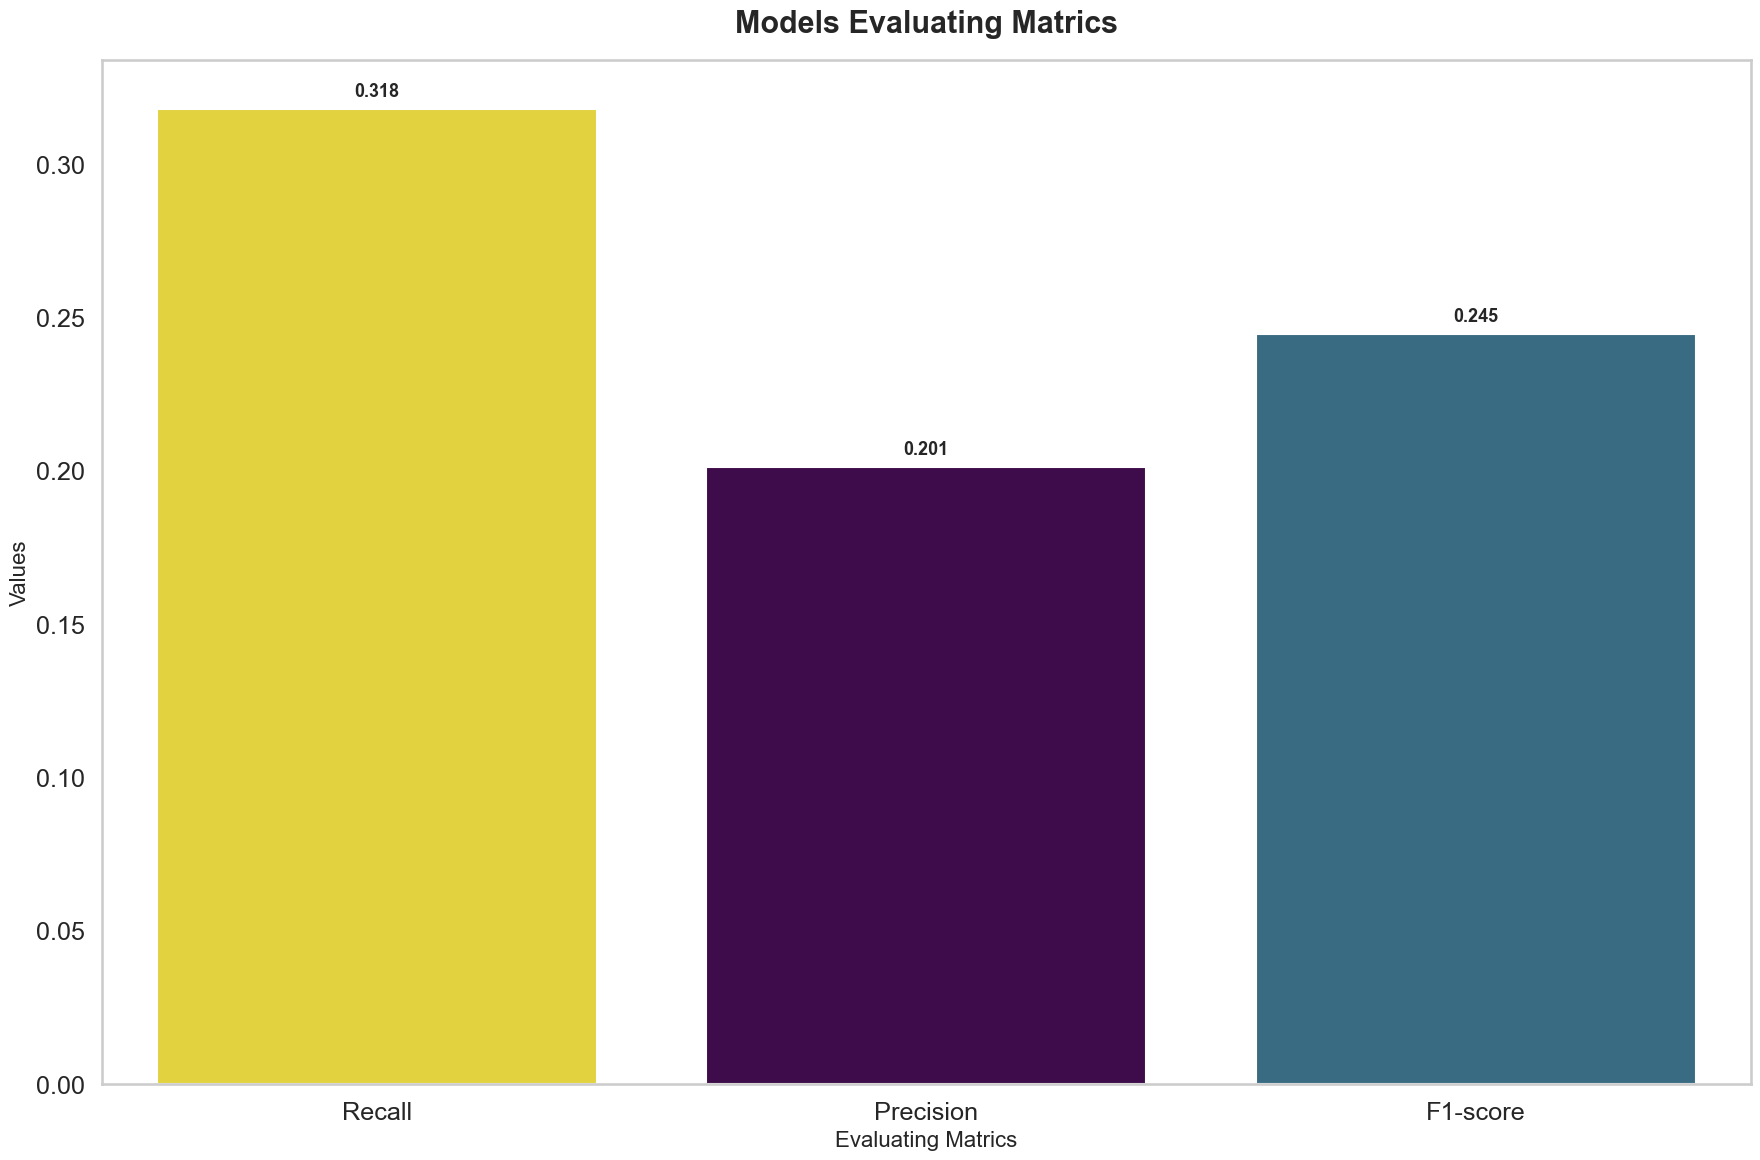

In [250]:
sns.set_theme(style="whitegrid",context="talk",font_scale=1.1)
plt.figure(figsize=(18, 12))

ax = sns.barplot(y=acc.values(),x=acc.keys(),palette="viridis",hue=acc.values(),legend=False)

ax.set_title("Models Evaluating Matrics",fontsize=22,weight="bold",pad=20)

ax.set_xlabel("Evaluating Matrics", fontsize=16)
ax.set_ylabel("Values", fontsize=16)

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=6, fontsize=13,weight="bold")
plt.grid(visible=False)
plt.tight_layout()
plt.show()

---

<h1 align="center">The End of model 😎</h1>


---